<a href="https://colab.research.google.com/github/JosephBless/Deep-Learning-Colab/blob/main/Day23%EF%BC%9A%E5%9F%BA%E6%9C%AC%E9%9D%A2%E7%A0%94%E7%A9%B6_%E8%B2%A1%E5%8B%99%E6%95%B8%E6%93%9A%E5%88%86%E6%9E%90%E8%88%87%E5%8F%AF%E8%A6%96%E5%8C%96.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

在之前的章節中我們針對了技術面以及市場情序進行了探討，在本課中，我們將學習基本面的範疇，包含如何分析企業的財務數據，包括營收、淨利潤和成長率等關鍵指標。我們將使用 Python 進行數據處理，並繪製河流圖（Sankey Diagram）、成長圖等，來直觀地展示企業的財務狀況和成長趨勢。[今日 Colab](https://colab.research.google.com/drive/1Cmpx8Ky-trVHw3uT2r6ltVRQEB1-A3gs?usp=sharing)


In [ ]:
# Colab 進行matplotlib繪圖時顯示繁體中文
# 下載台北思源黑體並命名taipei_sans_tc_beta.ttf，移至指定路徑
!wget -O TaipeiSansTCBeta-Regular.ttf https://drive.google.com/uc?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_&export=download

import matplotlib

# 改style要在改font之前
# plt.style.use('seaborn')

matplotlib.font_manager.fontManager.addfont('TaipeiSansTCBeta-Regular.ttf')
matplotlib.rc('font', family='Taipei Sans TC Beta')

--2024-10-08 03:39:48--  https://drive.google.com/uc?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_
Resolving drive.google.com (drive.google.com)... 108.177.119.138, 108.177.119.139, 108.177.119.102, ...
Connecting to drive.google.com (drive.google.com)|108.177.119.138|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_ [following]
--2024-10-08 03:39:48--  https://drive.usercontent.google.com/download?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 108.177.127.132, 2a00:1450:4013:c07::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|108.177.127.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 20659344 (20M) [application/octet-stream]
Saving to: ‘TaipeiSansTCBeta-Regular.ttf’

TaipeiSansTCBeta-Re 100%[===================>]  19.70M  --.-KB/s    in 0.1s    

2024-10-08 

## **一、引言**

### **1. 為什麼要分析財務數據？**

- **評估企業健康狀況**：瞭解企業的營收和利潤情況，有助於評估其經營狀況。
- **投資決策參考**：財務指標是投資者做出決策的重要依據。
- **發現趨勢**：通過歷史數據分析，可以預測未來的發展方向。
![https://ithelp.ithome.com.tw/upload/images/20241008/201205491OdSCdHpsN.jpg](https://ithelp.ithome.com.tw/upload/images/20241008/201205491OdSCdHpsN.jpg)

### **2. 本課目標**

- 獲取並整理企業的財務數據。
- 計算關鍵財務指標，如營收增長率、淨利潤率等。
- 使用可視化工具繪製河流圖、成長圖等，展示數據分析結果。

---

## **二、環境設置**

### **1. 安裝必要的庫**

我們需要以下 Python 庫：
- **Pandas**：數據處理和分析。
- **NumPy**：科學計算。
- **Matplotlib**：數據可視化。
- **Seaborn**：高階數據可視化。
- **YFinance**：獲取金融數據。
- **Requests**：HTTP 請求，用於獲取網絡數據。
- **Plotly**：互動式數據可視化。

In [ ]:
!pip install pandas numpy matplotlib seaborn
!pip install yfinance
!pip install requests
!pip install plotly

### **2. 導入庫**


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import requests
import plotly.graph_objects as go

## **三、數據獲取**

### **1. 從 FinancialModelingPrep 獲取財務數據**

![https://ithelp.ithome.com.tw/upload/images/20241008/20120549a7uqF78hVE.jpg](https://ithelp.ithome.com.tw/upload/images/20241008/20120549a7uqF78hVE.jpg)

我們將使用 FinancialModelingPrep（FMP）API 來獲取企業的財務報表數據。您需要在 [FMP 官網](https://financialmodelingprep.com/) 註冊並獲取 API 金鑰。另外也推薦看看[這個連結](https://buffettonlineschool.com.tw/financial_statements/)學怎麼看財報！

In [ ]:
# 替換為您的 FMP API 金鑰
api_key = 'YOUR_FMP_API_KEY'

# 定義要分析的公司，例如 Apple（AAPL）
symbol = 'AAPL'

### **2. 獲取財務報表**

#### **(1) 損益表（Income Statement）**

In [ ]:
income_statement_url = f'https://financialmodelingprep.com/api/v3/income-statement/{symbol}?limit=10&apikey={api_key}'
income_statement = requests.get(income_statement_url).json()

import json
income_statement_str = json.dumps(income_statement, indent=2)
print(income_statement_str)

[
  {
    "date": "2023-09-30",
    "symbol": "AAPL",
    "reportedCurrency": "USD",
    "cik": "0000320193",
    "fillingDate": "2023-11-03",
    "acceptedDate": "2023-11-02 18:08:27",
    "calendarYear": "2023",
    "period": "FY",
    "revenue": 383285000000,
    "costOfRevenue": 214137000000,
    "grossProfit": 169148000000,
    "grossProfitRatio": 0.4413112958,
    "researchAndDevelopmentExpenses": 29915000000,
    "generalAndAdministrativeExpenses": 0,
    "sellingAndMarketingExpenses": 0,
    "sellingGeneralAndAdministrativeExpenses": 24932000000,
    "otherExpenses": 382000000,
    "operatingExpenses": 55229000000,
    "costAndExpenses": 269366000000,
    "interestIncome": 3750000000,
    "interestExpense": 3933000000,
    "depreciationAndAmortization": 11519000000,
    "ebitda": 125820000000,
    "ebitdaratio": 0.3282674772,
    "operatingIncome": 114301000000,
    "operatingIncomeRatio": 0.2982141227,
    "totalOtherIncomeExpensesNet": 565000000,
    "incomeBeforeTax": 113736

#### **(2) 資產負債表（Balance Sheet）**

In [ ]:
balance_sheet_url = f'https://financialmodelingprep.com/api/v3/balance-sheet-statement/{symbol}?limit=10&apikey={api_key}'
balance_sheet = requests.get(balance_sheet_url).json()

import json
balance_sheet_str = json.dumps(balance_sheet, indent=2)
print(balance_sheet_str)

[
  {
    "date": "2023-09-30",
    "symbol": "AAPL",
    "reportedCurrency": "USD",
    "cik": "0000320193",
    "fillingDate": "2023-11-03",
    "acceptedDate": "2023-11-02 18:08:27",
    "calendarYear": "2023",
    "period": "FY",
    "cashAndCashEquivalents": 29965000000,
    "shortTermInvestments": 31590000000,
    "cashAndShortTermInvestments": 61555000000,
    "netReceivables": 60985000000,
    "inventory": 6331000000,
    "otherCurrentAssets": 14695000000,
    "totalCurrentAssets": 143566000000,
    "propertyPlantEquipmentNet": 54376000000,
    "goodwill": 0,
    "intangibleAssets": 0,
    "goodwillAndIntangibleAssets": 0,
    "longTermInvestments": 100544000000,
    "taxAssets": 17852000000,
    "otherNonCurrentAssets": 36245000000,
    "totalNonCurrentAssets": 209017000000,
    "otherAssets": 0,
    "totalAssets": 352583000000,
    "accountPayables": 62611000000,
    "shortTermDebt": 17382000000,
    "taxPayables": 8819000000,
    "deferredRevenue": 8061000000,
    "otherCurr

#### **(3) 現金流量表（Cash Flow Statement）**


In [ ]:
cash_flow_url = f'https://financialmodelingprep.com/api/v3/cash-flow-statement/{symbol}?limit=10&apikey={api_key}'
cash_flow = requests.get(cash_flow_url).json()

import json
cash_flow_str = json.dumps(cash_flow, indent=2)
print(cash_flow_str)

[
  {
    "date": "2023-09-30",
    "symbol": "AAPL",
    "reportedCurrency": "USD",
    "cik": "0000320193",
    "fillingDate": "2023-11-03",
    "acceptedDate": "2023-11-02 18:08:27",
    "calendarYear": "2023",
    "period": "FY",
    "netIncome": 96995000000,
    "depreciationAndAmortization": 11519000000,
    "deferredIncomeTax": 0,
    "stockBasedCompensation": 10833000000,
    "changeInWorkingCapital": -6577000000,
    "accountsReceivables": -1688000000,
    "inventory": -1618000000,
    "accountsPayables": -1889000000,
    "otherWorkingCapital": -2653000000,
    "otherNonCashItems": -2227000000,
    "netCashProvidedByOperatingActivities": 110543000000,
    "investmentsInPropertyPlantAndEquipment": -10959000000,
    "acquisitionsNet": 0,
    "purchasesOfInvestments": -29513000000,
    "salesMaturitiesOfInvestments": 45514000000,
    "otherInvestingActivites": -1337000000,
    "netCashUsedForInvestingActivites": 3705000000,
    "debtRepayment": -5923000000,
    "commonStockIssued

## **四、數據處理**

### **1. 將數據轉換為 DataFrame**

In [ ]:
income_df = pd.DataFrame(income_statement)
balance_df = pd.DataFrame(balance_sheet)
cash_flow_df = pd.DataFrame(cash_flow)

### **2. 選擇需要的欄位**

我們將關注以下指標：

- **營收（Revenue）**：企業在一定期間內通過銷售產品或提供服務所獲得的總收入。營收是評估企業市場份額和經營能力的基本指標。

- **淨利潤（Net Income）**：在扣除所有成本、費用、利息和稅金後的最終利潤。淨利潤反映了企業的盈利能力，是投資者關注的核心數據。

- **總資產（Total Assets）**：企業擁有的所有資產總額，包括現金、應收賬款、固定資產等。總資產可以衡量企業的規模和資源豐富程度。

- **股東權益（Total Stockholders Equity）**：企業的淨資產，即總資產減去總負債。股東權益代表了股東在企業中的權益，是評估財務健康和風險的重要指標。

我們選擇這些指標是因為它們能夠提供關於企業收入來源、盈利能力、資產狀況和財務穩健性的全面視圖，有助於我們深入分析企業的財務表現。


In [ ]:
financial_data = income_df[['date', 'revenue', 'netIncome', 'costOfRevenue', 'grossProfit', 'operatingExpenses']].copy()
financial_data['totalAssets'] = balance_df['totalAssets']
financial_data['totalEquity'] = balance_df['totalStockholdersEquity']
financial_data['freeCashFlow'] = cash_flow_df['freeCashFlow']

### **3. 轉換日期格式**

In [ ]:
financial_data['date'] = pd.to_datetime(financial_data['date'])
financial_data.sort_values('date', inplace=True)
financial_data.reset_index(drop=True, inplace=True)

### **4. 計算成長率和比率**

我們將計算以下財務指標：

#### **(1) 營收增長率（Revenue Growth Rate）**

**公式**：

$$
\text{營收增長率} = \frac{\text{本期營收} - \text{上期營收}}{\text{上期營收}}
$$

**Python 實現**：

In [ ]:
financial_data['revenueGrowth'] = financial_data['revenue'].pct_change()


**解釋**：

- **營收增長率**衡量了企業營收的成長速度，反映了企業的市場拓展和產品銷售情況。

#### **(2) 淨利潤率（Net Profit Margin）**

**公式**：

$$
\text{淨利潤率} = \frac{\text{淨利潤}}{\text{營收}}
$$

**Python 實現**：

In [ ]:
financial_data['netProfitMargin'] = financial_data['netIncome'] / financial_data['revenue']

**解釋**：

- **淨利潤率**表示每一美元營收中有多少轉化為淨利潤，反映了企業的盈利效率和成本控制能力。

#### **(3) 資產回報率（Return on Assets，ROA）**

**公式**：

$$
\text{ROA} = \frac{\text{淨利潤}}{\text{總資產}}
$$

**Python 實現**：

In [ ]:
financial_data['ROA'] = financial_data['netIncome'] / financial_data['totalAssets']


**解釋**：

- **ROA**衡量企業使用其資產產生利潤的能力，資產利用效率的指標。

#### **(4) 股東權益回報率（Return on Equity，ROE）**

**公式**：

$$
\text{ROE} = \frac{\text{淨利潤}}{\text{股東權益}}
$$

**Python 實現**：

In [ ]:
financial_data['ROE'] = financial_data['netIncome'] / financial_data['totalEquity']


**解釋**：

- **ROE**衡量股東投資獲得的回報率，評估股東權益的收益能力。

---

## **五、數據可視化**

### **1. 營收和淨利潤趨勢圖**

我們將繪製營收和淨利潤隨時間變化的趨勢圖，以觀察它們的走勢和關係。

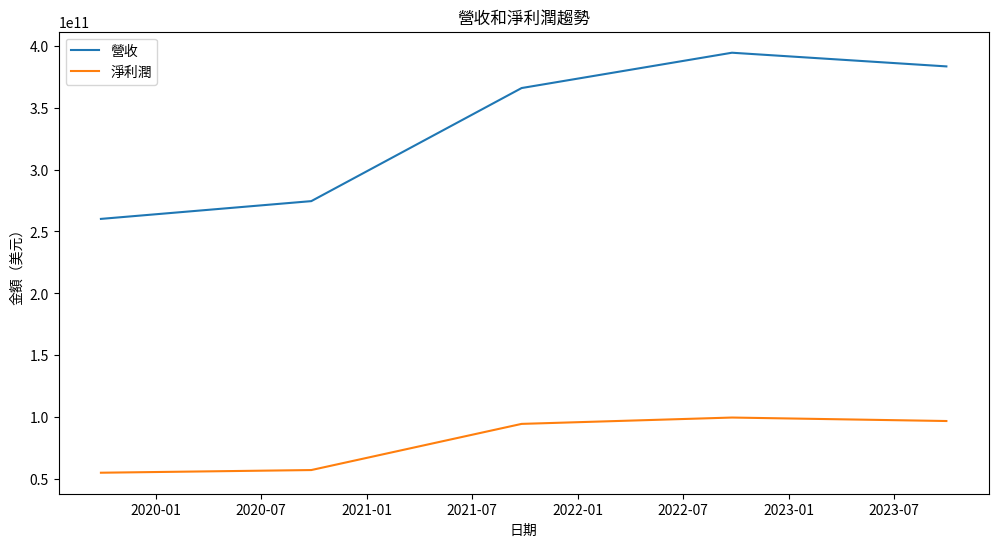

In [ ]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=financial_data, x='date', y='revenue', label='營收')
sns.lineplot(data=financial_data, x='date', y='netIncome', label='淨利潤')
plt.title('營收和淨利潤趨勢')
plt.xlabel('日期')
plt.ylabel('金額（美元）')
plt.legend()
plt.show()

### **2. 營收增長率**

繪製營收增長率的柱狀圖，直觀展示營收增長的速度和波動。

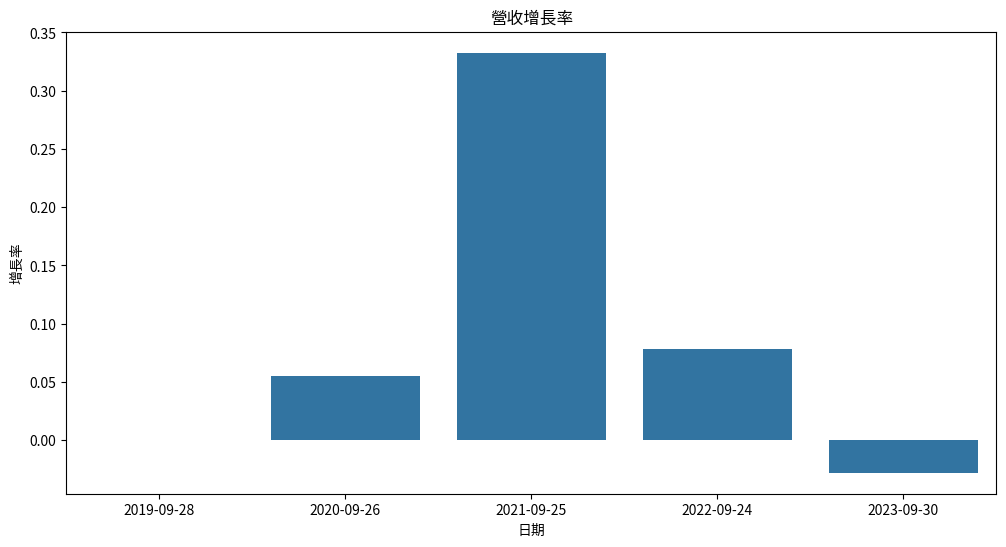

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(data=financial_data, x='date', y='revenueGrowth')
plt.title('營收增長率')
plt.xlabel('日期')
plt.ylabel('增長率')
plt.show()

### **3. 淨利潤率、ROA、ROE**

將淨利潤率、ROA、ROE 繪製在同一圖表中，方便比較各指標的變化。

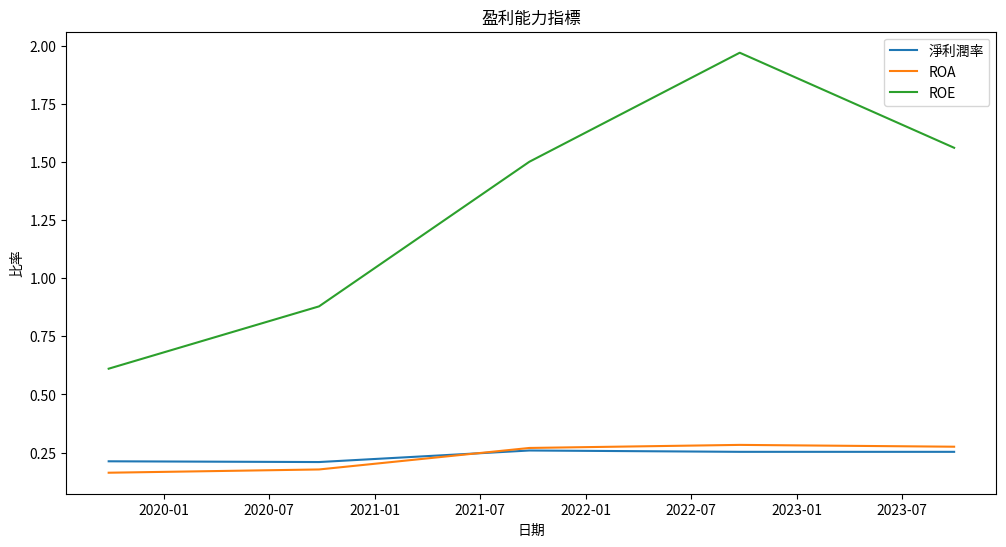

In [ ]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=financial_data, x='date', y='netProfitMargin', label='淨利潤率')
sns.lineplot(data=financial_data, x='date', y='ROA', label='ROA')
sns.lineplot(data=financial_data, x='date', y='ROE', label='ROE')
plt.title('盈利能力指標')
plt.xlabel('日期')
plt.ylabel('比率')
plt.legend()
plt.show()

### **4. 河流圖（Sankey Diagram）**

河流圖可以直觀地展示資金或能量的流動。在財務分析中，我們可以使用河流圖來展示營收如何被分配到成本、費用，最終得到淨利潤。

**解釋**：

- **節點（Nodes）**：代表財務報表中的不同項目，如營收、成本、毛利等。
- **連結（Links）**：表示資金從一個節點流向另一個節點的數量。

**程式碼**：

In [ ]:
# 準備數據
labels = ['營收', '營業成本', '毛利', '營業費用', '淨利潤']
sources = [0, 0, 2, 2]  # 資金流的起始節點
targets = [2, 1, 3, 4]  # 資金流的目標節點
values = [
    financial_data['revenue'].iloc[-1],  # 營收
    -financial_data['costOfRevenue'].iloc[-1],  # 負的營業成本
    financial_data['grossProfit'].iloc[-1],  # 毛利
    -financial_data['operatingExpenses'].iloc[-1],  # 負的營業費用
]

# 建立河流圖
fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=labels,
    ),
    link=dict(
        source=sources,
        target=targets,
        value=values
    ))])

fig.update_layout(title_text="財務河流圖", font_size=10)
fig.show()

**說明**：
​
- **節點（Nodes）**：
​
  - **營收**：企業的總收入。
  - **營業成本**：生產產品或提供服務的直接成本。
  - **毛利**：營收減去營業成本，即企業在扣除直接成本後剩餘的收入。
  - **營業費用**：企業運營所需的間接費用，如管理費、銷售費用。
  - **淨利潤**：最終利潤，毛利減去營業費用。
​
- **連結（Links）**：
​
  - **營收到毛利**：營收減去營業成本，得到毛利。
  - **營收到營業成本**：表示營收的一部分用於支付營業成本。
  - **毛利到營業費用**：毛利減去營業費用。
  - **毛利到淨利潤**：最終得到淨利潤。
​
- **視覺化效果**：
​
  - **流的寬度**：代表資金流的大小，寬度越寬，數額越大。
  - **顏色**：不同的流和節點可以設置不同的顏色，以便區分。
​
---
​
## **六、結果分析**
​
### **1. 營收與淨利潤趨勢**
​
- **觀察點**：營收和淨利潤是否呈現同步增長，還是存在背離。
- **解釋**：如果營收增長但淨利潤下降，可能是成本增加或利潤率降低，需要進一步分析原因。
​
### **2. 盈利能力指標**
​
- **淨利潤率**：高淨利潤率表示企業有較強的成本控制和定價能力。
- **ROA**：高 ROA 表示資產利用效率高，資產產生利潤的能力強。
- **ROE**：高 ROE 表示股東投資獲得較高的回報，但需要警惕過高的負債比例。
​
### **3. 成長率分析**
​
- **營收增長率**：持續的高增長率表明企業具有良好的市場競爭力和發展前景。
- **變化趨勢**：增長率的波動可能預示市場環境的變化或企業自身的挑戰。
​
### **4. 河流圖解讀**
​
- **資金流動**：從營收開始，經過營業成本和營業費用的扣除，最終得到淨利潤。
- **成本結構**：河流圖直觀地展示了成本和費用在總收入中的佔比，有助於識別成本控制的重點領域。
- **利潤貢獻**：可以看到哪部分成本或費用對淨利潤影響最大，為決策提供依據。
​
---
​
## **七、完整程式碼**

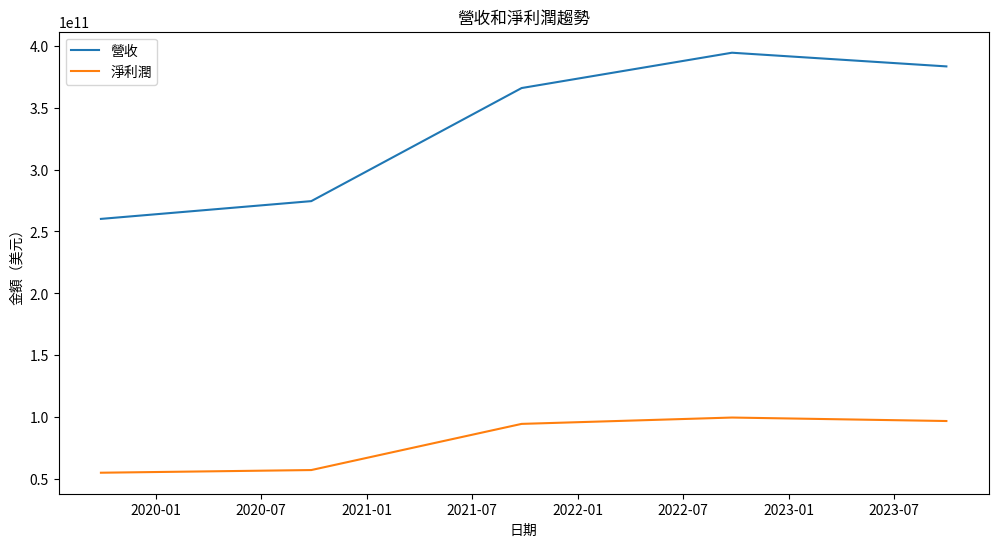

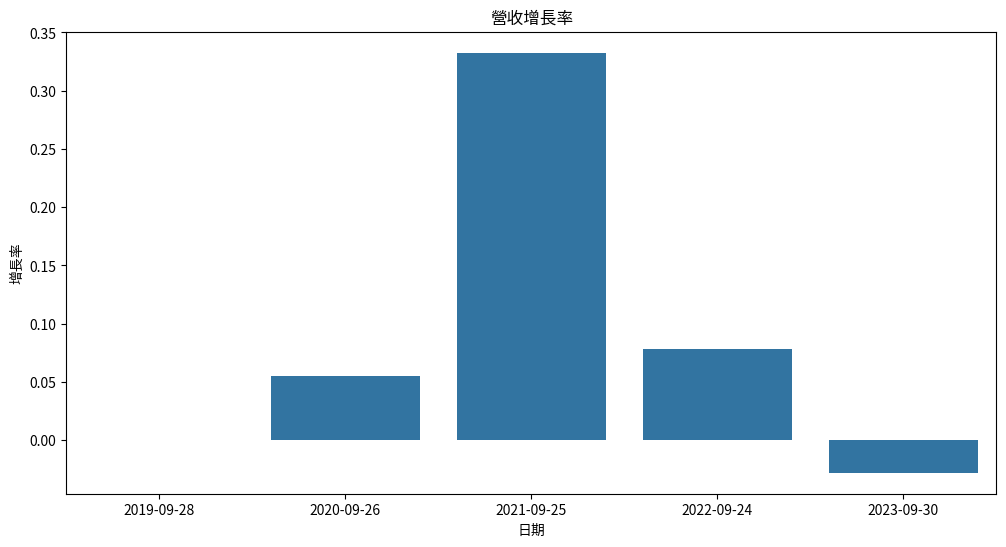

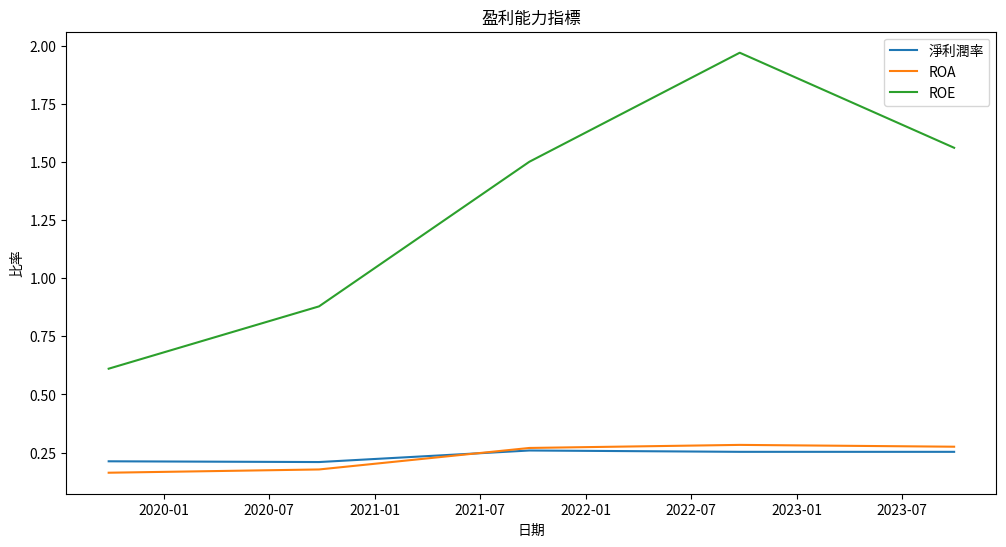

In [ ]:
# 安裝必要的庫
!pip install pandas numpy matplotlib seaborn
!pip install yfinance
!pip install requests
!pip install plotly

# 導入庫
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import requests
import plotly.graph_objects as go

# 替換為您的 FMP API 金鑰
api_key = 'YOUR_FMP_API_KEY'

# 定義要分析的公司
symbol = 'AAPL'

# 獲取財務報表
income_statement_url = f'https://financialmodelingprep.com/api/v3/income-statement/{symbol}?limit=10&apikey={api_key}'
income_statement = requests.get(income_statement_url).json()

balance_sheet_url = f'https://financialmodelingprep.com/api/v3/balance-sheet-statement/{symbol}?limit=10&apikey={api_key}'
balance_sheet = requests.get(balance_sheet_url).json()

cash_flow_url = f'https://financialmodelingprep.com/api/v3/cash-flow-statement/{symbol}?limit=10&apikey={api_key}'
cash_flow = requests.get(cash_flow_url).json()

# 轉換為 DataFrame
income_df = pd.DataFrame(income_statement)
balance_df = pd.DataFrame(balance_sheet)
cash_flow_df = pd.DataFrame(cash_flow)

# 選擇需要的欄位
financial_data = income_df[['date', 'revenue', 'netIncome', 'costOfRevenue', 'grossProfit', 'operatingExpenses']].copy()
financial_data['totalAssets'] = balance_df['totalAssets']
financial_data['totalEquity'] = balance_df['totalStockholdersEquity']
financial_data['freeCashFlow'] = cash_flow_df['freeCashFlow']

# 轉換日期格式
financial_data['date'] = pd.to_datetime(financial_data['date'])
financial_data.sort_values('date', inplace=True)
financial_data.reset_index(drop=True, inplace=True)

# 計算成長率和比率
financial_data['revenueGrowth'] = financial_data['revenue'].pct_change()
financial_data['netProfitMargin'] = financial_data['netIncome'] / financial_data['revenue']
financial_data['ROA'] = financial_data['netIncome'] / financial_data['totalAssets']
financial_data['ROE'] = financial_data['netIncome'] / financial_data['totalEquity']

# 可視化

## 營收和淨利潤趨勢圖
plt.figure(figsize=(12, 6))
sns.lineplot(data=financial_data, x='date', y='revenue', label='營收')
sns.lineplot(data=financial_data, x='date', y='netIncome', label='淨利潤')
plt.title('營收和淨利潤趨勢')
plt.xlabel('日期')
plt.ylabel('金額（美元）')
plt.legend()
plt.show()

## 營收增長率
plt.figure(figsize=(12, 6))
sns.barplot(data=financial_data, x='date', y='revenueGrowth')
plt.title('營收增長率')
plt.xlabel('日期')
plt.ylabel('增長率')
plt.show()

## 淨利潤率、ROA、ROE
plt.figure(figsize=(12, 6))
sns.lineplot(data=financial_data, x='date', y='netProfitMargin', label='淨利潤率')
sns.lineplot(data=financial_data, x='date', y='ROA', label='ROA')
sns.lineplot(data=financial_data, x='date', y='ROE', label='ROE')
plt.title('盈利能力指標')
plt.xlabel('日期')
plt.ylabel('比率')
plt.legend()
plt.show()

## 河流圖
labels = ['Revenue', 'Cost of Revenue', 'Gross Profit', 'Operating Expenses', 'Net Income']
sources = [0, 0, 2, 2]
targets = [2, 1, 3, 4]
values = [
    financial_data['revenue'].iloc[-1],
    -financial_data['costOfRevenue'].iloc[-1],
    financial_data['grossProfit'].iloc[-1],
    -financial_data['operatingExpenses'].iloc[-1],
]

fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=labels,
    ),
    link=dict(
        source=sources,
        target=targets,
        value=values
    ))])

fig.update_layout(title_text="財務河流圖", font_size=10)
fig.show()


## **八、作業**

1. **分析其他公司**：選擇另一家您感興趣的公司，重複以上分析步驟。
2. **添加更多指標**：如現金流量、負債比率等，進行更全面的財務分析。
3. **比較多家公司**：將多家公司的財務指標進行比較，找出優劣勢。
4. **優化可視化效果**：嘗試使用其他可視化工具或圖表，提升圖表的美觀和信息傳達效率。

---

## **提示**

- **數據質量**：確保獲取的數據完整且準確，特別是處理缺失值時要小心。
- **API 限制**：注意 API 的使用限制，如每分鐘請求次數等。
- **可視化技巧**：選擇合適的圖表類型，調整配色和標籤，使圖表易於理解。

---

## **注意事項**

- **API 金鑰安全性**：請勿將您的 API 金鑰公開分享，確保金鑰的安全。
- **合規要求**：遵守各數據來源的使用條款和法律法規。
- **風險提示**：財務分析僅供參考，投資需謹慎。

---

*希望通過本課的學習，能夠掌握財務數據的分析方法，並能夠運用可視化工具直觀地展示分析結果。*